In [2]:
# 필요한 라이브러리 임포트
import numpy as np                                                # 수치 계산 및 행렬(Array) 처리
import pandas as pd                                               # 데이터 분석 및 표(DataFrame) 관리
import matplotlib.pyplot as plt                                   # 데이터 시각화 및 그래프 작성

import statsmodels.api as sm                                      # 통계 모델링 및 상세 분석 결과 보고

from sklearn import datasets                                      # 머신러닝 연습용 데이터셋 로딩
from sklearn.model_selection import train_test_split              # 데이터를 학습용과 테스트용으로 분리
from sklearn.linear_model import LinearRegression, Ridge, Lasso   # 선형, 릿지, 라쏘 회귀 모델
from sklearn.metrics import mean_squared_error, r2_score          # 모델이 얼마나 잘 맞는지 평가 (오차, 결정계수)

In [3]:
# 데이터 로딩
diabetes = datasets.load_diabetes()                               # 사이킷런에서 제공하는 당뇨병 데이터셋 전체를 불러옴
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)   # 예측에 사용할 '원인' 데이터(나이, 혈압 등)를 표 형태로 변환
y = diabetes.target                                               # 우리가 맞히고자 하는 '결과' 데이터(당뇨 진행도)를 저장
feature_names = diabetes.feature_names                            # 데이터에 포함된 항목들(나이, 성별, BMI 등)의 이름을 따로 저장

In [4]:
print(X)
print()
print(y)
print()
print(feature_names)

          age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  
0   -0.002592  0.019907 -0.017646  
1  

# Hypothesis Testing

In [5]:
# Multiple Regression (다중 선형 회귀 분석)
model = sm.OLS(y, X)      # 최소자승법(OLS) 방식의 회귀 모델 생성 (y: 타겟, X: 특징 데이터)
result = model.fit()      # 모델 학습 수행 (데이터에 가장 잘 맞는 회귀계수 찾기)
print(result.summary())   # 학습된 모델의 상세 통계 요약 리포트 출력

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.106
Model:                            OLS   Adj. R-squared (uncentered):              0.085
Method:                 Least Squares   F-statistic:                              5.100
Date:                Sun, 22 Mar 2026   Prob (F-statistic):                    4.72e-07
Time:                        19:49:33   Log-Likelihood:                         -2873.9
No. Observations:                 442   AIC:                                      5768.
Df Residuals:                     432   BIC:                                      5809.
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

# Shrinkage Models

In [6]:
# 데이터를 학습용(Train)과 테스트용(Test)으로 분리 (8:2 비율)
# random_state=42는 실행할 때마다 동일하게 분리되도록 고정하는 난수
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scikit-learn의 선형 회귀(Linear Regression) 모델 객체 생성
lin_reg = LinearRegression()

# 학습용 데이터(X_train, y_train)를 사용하여 모델 학습 (공식 찾기)
lin_reg.fit(X_train, y_train)

# 학습된 모델을 사용하여 예측 수행
y_train_pred = lin_reg.predict(X_train) # 학습 데이터에 대한 예측값
y_test_pred = lin_reg.predict(X_test)   # 테스트 데이터(새로운 데이터)에 대한 예측값

# MSE(평균 제곱 오차) 계산: 실제값과 예측값의 차이를 제곱하여 평균낸 것 (낮을수록 좋음)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# R-squared(결정계수) 계산: 모델이 데이터를 얼마나 잘 설명하는지 (1에 가까울수록 좋음)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 최종 결과 출력
print(f"Linear Regression Coefficients: {lin_reg.coef_}") # 모델이 찾은 각 변수의 가중치(기울기)
print(f"Train MSE: {train_mse}") # 학습 데이터에서의 오차
print(f"Test MSE: {test_mse}")   # 테스트 데이터에서의 오차 (실제 모델의 예측 성능)
print(f"Train R2: {train_r2}")   # 학습 데이터 설명력
print(f"Test R2: {test_r2}")     # 테스트 데이터 설명력

Linear Regression Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Train MSE: 2868.5497028355776
Test MSE: 2900.1936284934804
Train R2: 0.5279193863361498
Test R2: 0.4526027629719197


In [7]:
# Ridge 회귀 모델 객체 생성
# alpha는 규제의 강도를 조절, 값이 클수록 모델을 더 단순하게
ridge_reg = Ridge(alpha=1.0)

# 학습용 데이터를 사용하여 Ridge 모델 학습 (가중치 계산)
ridge_reg.fit(X_train, y_train)

# 학습된 모델로 예측값 계산
y_train_pred = ridge_reg.predict(X_train) # 학습 데이터에 대한 예측
y_test_pred = ridge_reg.predict(X_test)   # 테스트 데이터에 대한 예측

# MSE(평균 제곱 오차) 계산: 오차가 작을수록 모델의 성능이 좋음
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# R-squared(결정계수) 계산: 모델이 데이터를 얼마나 잘 설명하는지
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 최종 결과 출력
print(f"Ridge Regression Coefficients: {ridge_reg.coef_}") # 모델이 찾은 변수별 가중치
print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")
print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")

Ridge Regression Coefficients: [  45.36737726  -76.66608563  291.33883165  198.99581745   -0.53030959
  -28.57704987 -144.51190505  119.26006559  230.22160832  112.14983004]
Train MSE: 3388.1826180801304
Test MSE: 3077.41593882723
Train R2: 0.4424027835503953
Test R2: 0.41915292635986545


In [8]:
# Lasso 회귀 모델 객체 생성
# alpha는 규제의 강도를 조절 (기본값 1.0)
lasso_reg = Lasso(alpha=1.0)

# 학습용 데이터를 사용하여 Lasso 모델 학습 (가중치 계산)
lasso_reg.fit(X_train, y_train)

# 학습된 모델로 예측값 계산
y_train_pred = lasso_reg.predict(X_train) # 학습 데이터에 대한 예측
y_test_pred = lasso_reg.predict(X_test)   # 테스트 데이터에 대한 예측

# MSE(평균 제곱 오차) 계산: 예측값과 실제값의 차이를 평가
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# R-squared(결정계수) 계산: 모델의 설명력을 확인
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 최종 결과 출력
print(f"Lasso Regression Coefficients: {lasso_reg.coef_}") # 모델이 찾은 변수별 가중치
print(f"Train MSE: {train_mse}")
print(f"Test MSE: {test_mse}")
print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")

Lasso Regression Coefficients: [  0.          -0.         413.43184792  34.83051518   0.
   0.          -0.           0.         258.15289363   0.        ]
Train MSE: 3860.7549830123576
Test MSE: 3403.5757216070733
Train R2: 0.3646309911295581
Test R2: 0.3575918767219115


# Lasso vs Ridge

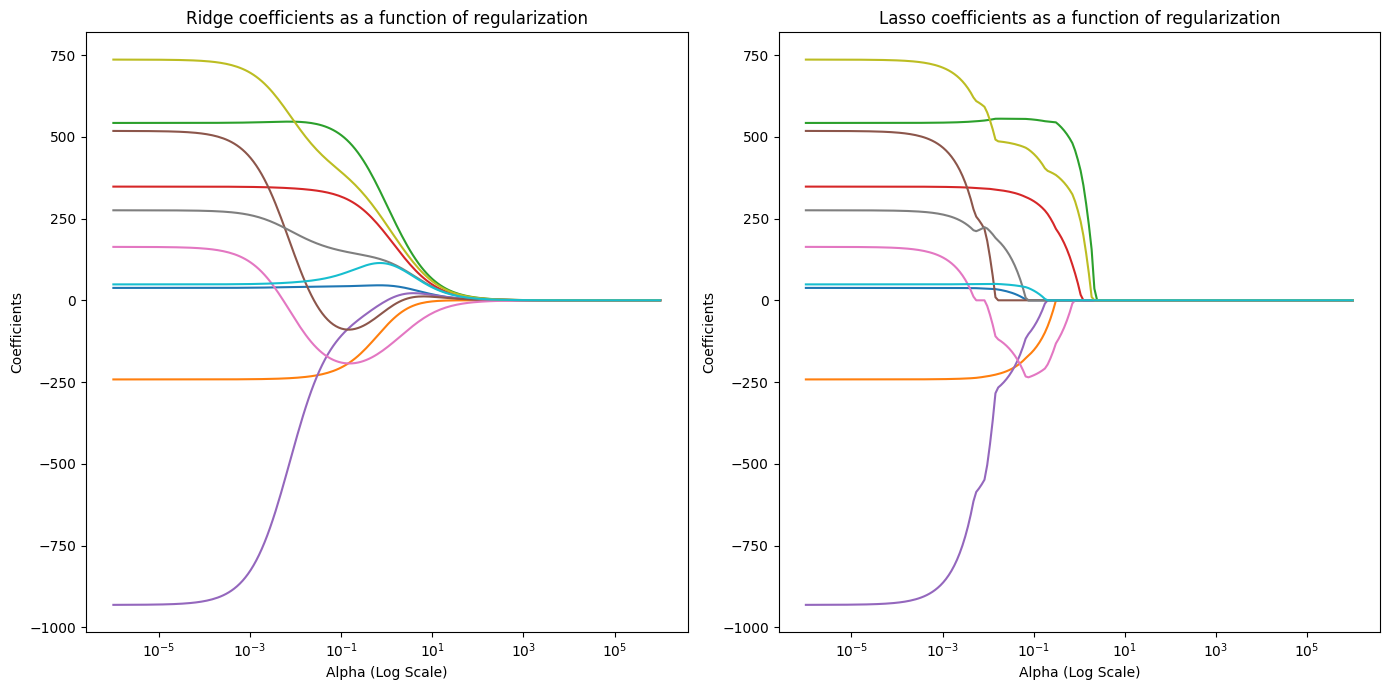

In [9]:
# Alpha 값 설정 (10의 -6승부터 10의 6승까지 로그 스케일로 200개 생성)
alphas = np.logspace(-6, 6, 200)

# 계수 변화를 저장하기 위한 리스트 초기화
ridge_coefs = []
lasso_coefs = []

# 설정한 200개의 alpha 값을 하나씩 반복하며 모델 훈련
for alpha in alphas:
    # Ridge 모델 훈련 및 계수 저장
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)

    # Lasso 모델 훈련 및 계수 저장
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    lasso_coefs.append(lasso.coef_)

# 리스트 형태의 계수들을 계산과 시각화가 편하도록 numpy 배열로 변환
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# 시각화를 위한 캔버스 크기 설정
plt.figure(figsize=(14, 7))

# 1. Ridge 그래프 (왼쪽)
plt.subplot(121)
ax = plt.gca()
ax.plot(alphas, ridge_coefs)    # x축은 alpha, y축은 각 변수의 계수값
ax.set_xscale('log')            # alpha 값이 범위가 크므로 로그 스케일로 표시
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Coefficients')
plt.title('Ridge coefficients as a function of regularization')

# 2. Lasso 그래프 (오른쪽)
plt.subplot(122)
ax = plt.gca()
ax.plot(alphas, lasso_coefs)    # x축은 alpha, y축은 각 변수의 계수값
ax.set_xscale('log')            # 동일하게 로그 스케일 적용
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Coefficients')
plt.title('Lasso coefficients as a function of regularization')

plt.tight_layout() # 그래프 간 간격 자동 조정
plt.show()         # 화면에 출력